<a href="https://colab.research.google.com/github/leippold/finance-nlp-workshop/blob/main/colabs/latent_state_rung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rung 2 — latent state

**DEEP Learning Summer School 2026 · Session 1 · Foundations of Sequence Modelling**

The count table's context is the last $n-1$ **words**. This rung replaces that
with a distribution over $K$ hidden states — a learned summary of the *whole*
prefix, so information can travel arbitrarily far.

The lecture made four claims about it. Each gets a cell:

| claim | where |
|---|---|
| summing over $K^T$ state paths reduces to $O(TK^2)$ by keeping a sufficient statistic | §3 |
| the states are learned, not labelled — they become modes of the document | §5 |
| the belief state **is** the context map, and it is only $K-1$ numbers | §6, §7 |
| the same recursion with a Gaussian emission is Hamilton's regime-switching model | §8 |

§7 is the one that matters: it turns the bottleneck from an assertion into a
measurement. Sweep $K$, plot held-out perplexity, and see whether it saturates.

**Runtime.** ~4 minutes on CPU, under a minute on a T4. Everything is validated
against a planted HMM in §4 before it is used on anything real.

## 1 · Setup

`CONTACT` is only needed if the corpus cache is empty — the SEC refuses requests
without a declared contact address.

In [1]:
CONTACT = "your.name@uzh.ch"          # <-- EDIT ME if the corpus is not cached

import re, json, gzip, math, time, pathlib, collections, urllib.request
import numpy as np, matplotlib.pyplot as plt
import torch

DEV   = "cuda" if torch.cuda.is_available() else "cpu"
CACHE = pathlib.Path("corpus_cache"); CACHE.mkdir(exist_ok=True)
torch.manual_seed(0); np.random.seed(0)
print(f"torch {torch.__version__} on {DEV}")

torch 2.11.0+cpu on cpu


## 2 · Corpus

The same filings as the Bengio notebook. If you ran that one in this session the
cache is already warm and this takes no time at all.

In [2]:
UA = f"DEEP Summer School 2026 teaching notebook ({CONTACT})"
CIKS = {"NextEra":753308,"Duke":1326160,"Exxon":34088,"Chevron":93410,"AIG":5272,
        "Travelers":86312,"Prologis":1045609,"Dow":1751788,"Southern":92122,
        "Dominion":715957,"ConocoPhillips":1163165,"Caterpillar":18230,
        "Deere":315189,"UnionPacific":100885,"Alcoa":1675149,"Nucor":73309,
        "Marsh":62709,"Chubb":896159,"KinderMorgan":1506307,"Sempra":1032208}

def _get(url, tries=3):
    for k in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": UA})
            with urllib.request.urlopen(req, timeout=60) as r: raw = r.read()
            return gzip.decompress(raw) if raw[:2] == b"\x1f\x8b" else raw
        except Exception:
            if k == tries - 1: raise
            time.sleep(1.5 * (k + 1))

def html_to_text(h):
    h = re.sub(r"(?is)<(script|style).*?</\1>", " ", h)
    t = re.sub(r"(?s)<[^>]+>", " ", h).replace("&nbsp;", " ").replace("&amp;", "&")
    return re.sub(r"\s+", " ", re.sub(r"&[a-zA-Z]+;|&#\d+;", " ", t)).strip()

def fetch(cik, n=2):
    d = json.loads(_get(f"https://data.sec.gov/submissions/CIK{str(cik).zfill(10)}.json").decode())
    rec, out = d["filings"]["recent"], []
    for i, f in enumerate(rec["form"]):
        if f == "10-K" and rec["primaryDocument"][i].endswith((".htm", ".html")):
            acc = rec["accessionNumber"][i].replace("-", "")
            key = CACHE / f"{cik}_{acc}.txt"
            if not key.exists():
                key.write_text(html_to_text(_get(
                    f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc}/"
                    f"{rec['primaryDocument'][i]}").decode("utf-8", errors="ignore")))
                time.sleep(0.2)
            out.append(key.read_text())
            if len(out) >= n: break
    return out

cached = sorted(CACHE.glob("*.txt"))
if len(cached) >= 20:
    raw_docs = [p.read_text() for p in cached]
    print(f"using {len(raw_docs)} cached filings")
else:
    t0, raw_docs = time.time(), []
    for nm, cik in CIKS.items():
        try: raw_docs += fetch(cik)
        except Exception: pass
    print(f"{len(raw_docs)} filings downloaded in {time.time()-t0:.0f}s")

TOKEN = re.compile(r"[a-z]+")
toks  = [[w for w in TOKEN.findall(d.lower()) if len(w) <= 18] for d in raw_docs]
order = np.random.default_rng(0).permutation(len(toks))
train_docs = [toks[i] for i in order[:int(.85*len(toks))]]
val_docs   = [toks[i] for i in order[int(.85*len(toks)):]]

VOCAB = 3_000
cnt   = collections.Counter(w for d in train_docs for w in d)
itos  = ["<unk>"] + [w for w, _ in cnt.most_common(VOCAB - 1)]
stoi  = {w: i for i, w in enumerate(itos)}
V     = len(itos)
print(f"{sum(map(len, toks)):,} tokens, vocabulary {V:,}, "
      f"{len(train_docs)} train / {len(val_docs)} held-out documents")

40 filings downloaded in 27s
3,553,337 tokens, vocabulary 3,000, 34 train / 6 held-out documents


In [3]:
SEQ_LEN, MAX_SEQ = 200, 4_000

def to_sequences(docs, seq_len=SEQ_LEN, max_seq=None, seed=0):
    ids = np.concatenate([np.array([stoi.get(w, 0) for w in d], np.int64) for d in docs])
    n   = len(ids) // seq_len
    S   = ids[:n * seq_len].reshape(n, seq_len)
    if max_seq and n > max_seq:
        S = S[np.random.default_rng(seed).permutation(n)[:max_seq]]
    return torch.from_numpy(S)

Xtr = to_sequences(train_docs, max_seq=MAX_SEQ)
Xva = to_sequences(val_docs,   max_seq=800)
print(f"train {tuple(Xtr.shape)} = {Xtr.numel():,} tokens | held out {tuple(Xva.shape)}")

train (4000, 200) = 800,000 tokens | held out (800, 200)


## 3 · The forward algorithm

The likelihood is a sum over every path the hidden state could have taken —
$K^T$ terms. For $K=8$ and one 200-word sequence that is $8^{200}$, a number
with 181 digits.

The recursion below evaluates it in $O(TK^2)$ by carrying **one $K$-vector**
forward instead of the histories. Everything is in log space: the raw
$\alpha_t$ underflows float64 after roughly 300 tokens, which is not a
hypothetical — it is the first thing that breaks when people implement this.

In [4]:
def log_forward(log_pi, log_A, logB):
    """logB: (N,L,K) emission log-probs. -> log_alpha (N,L,K), loglik (N,)"""
    N, L, K = logB.shape
    log_alpha = torch.empty(N, L, K, dtype=logB.dtype, device=logB.device)
    log_alpha[:, 0] = log_pi + logB[:, 0]
    for t in range(1, L):
        log_alpha[:, t] = torch.logsumexp(
            log_alpha[:, t-1].unsqueeze(2) + log_A.unsqueeze(0), dim=1) + logB[:, t]
    return log_alpha, torch.logsumexp(log_alpha[:, -1], dim=1)

def log_backward(log_A, logB):
    N, L, K = logB.shape
    log_beta = torch.zeros(N, L, K, dtype=logB.dtype, device=logB.device)
    for t in range(L - 2, -1, -1):
        log_beta[:, t] = torch.logsumexp(
            log_A.unsqueeze(0) + (logB[:, t+1] + log_beta[:, t+1]).unsqueeze(1), dim=2)
    return log_beta

def categorical_logB(X, log_B):      # log_B (K,V) -> (N,L,K)
    return log_B.T[X]

def gaussian_logB(y, mu, sigma):     # y (N,L); mu,sigma (K,) -> (N,L,K)
    z = (y.unsqueeze(-1) - mu) / sigma
    return -0.5 * z**2 - torch.log(sigma) - 0.5 * math.log(2 * math.pi)

K_demo = 8
print(f"paths through a length-{SEQ_LEN} sequence with K={K_demo}: "
      f"{K_demo}^{SEQ_LEN} ~ 10^{SEQ_LEN*math.log10(K_demo):.0f}")
print(f"operations with the forward recursion: {SEQ_LEN} x {K_demo}^2 = "
      f"{SEQ_LEN*K_demo**2:,}")

paths through a length-200 sequence with K=8: 8^200 ~ 10^181
operations with the forward recursion: 200 x 8^2 = 12,800


## 4 · Baum–Welch, and a check that it works

EM alternates two steps. **E**: set $q$ to the posterior over states, which makes
the lower bound touch the likelihood. **M**: maximise the bound — which turns out
to be *count and normalise with expected counts*, the bigram MLE with $\gamma$
and $\xi$ in place of raw counts.

Before running this on filings, plant a known 3-state HMM, sample from it, and
check the fitted parameters come back. If this cell does not recover the truth,
nothing downstream means anything.

In [5]:
def baum_welch_step(log_pi, log_A, logB):
    """One E-step plus the transition/initial M-step. Returns gamma for the
    emission M-step, and the total log-likelihood BEFORE the update."""
    N, L, K = logB.shape
    log_alpha, ll = log_forward(log_pi, log_A, logB)
    log_beta      = log_backward(log_A, logB)
    gamma = (log_alpha + log_beta - ll[:, None, None]).exp()
    xi = torch.zeros(K, K, dtype=logB.dtype, device=logB.device)
    for t in range(L - 1):
        xi += (log_alpha[:, t].unsqueeze(2) + log_A.unsqueeze(0)
               + (logB[:, t+1] + log_beta[:, t+1]).unsqueeze(1)
               - ll[:, None, None]).exp().sum(0)
    new_log_pi = torch.log(gamma[:, 0].sum(0) / N + 1e-30)
    new_log_A  = torch.log(xi / xi.sum(1, keepdim=True).clamp_min(1e-30) + 1e-30)
    return new_log_pi, new_log_A, gamma, ll.sum()

def m_step_categorical(X, gamma, V):
    K = gamma.shape[-1]
    B = torch.zeros(K, V, dtype=gamma.dtype, device=gamma.device)
    B.index_add_(1, X.reshape(-1), gamma.reshape(-1, K).T)
    return torch.log(B / B.sum(1, keepdim=True).clamp_min(1e-30) + 1e-30)

def m_step_gaussian(y, gamma):
    w  = gamma.reshape(-1, gamma.shape[-1]); yy = y.reshape(-1, 1)
    den = w.sum(0).clamp_min(1e-30)
    mu  = (w * yy).sum(0) / den
    var = (w * (yy - mu)**2).sum(0) / den
    return mu, var.clamp_min(1e-12).sqrt()

def fit_hmm_categorical(X, K, V, iters=40, seed=0, dtype=torch.float64, verbose=True):
    torch.manual_seed(seed)
    log_pi = torch.log(torch.ones(K, dtype=dtype) / K)
    log_A  = torch.log(torch.softmax(torch.randn(K, K, dtype=dtype)*.1
                                     + torch.eye(K, dtype=dtype)*2, dim=1))
    log_B  = torch.log(torch.softmax(torch.randn(K, V, dtype=dtype)*.5, dim=1))
    prev, hist = None, []
    for it in range(iters):
        log_pi, log_A, gamma, ll = baum_welch_step(log_pi, log_A,
                                                   categorical_logB(X, log_B))
        log_B = m_step_categorical(X, gamma, V)
        hist.append(ll.item() / X.numel())
        if prev is not None and ll.item() < prev - 1e-9*abs(prev):
            print(f"  !! likelihood decreased at iter {it} -- numerical, not EM")
        prev = ll.item()
        if verbose and (it % 10 == 0 or it == iters-1):
            print(f"  iter {it:>3}  loglik/token {hist[-1]:+.4f}")
    return log_pi, log_A, log_B, gamma, hist

In [6]:
# --- validation on a planted HMM -------------------------------------------
rng = np.random.default_rng(0)
A_t = np.array([[.85,.10,.05], [.05,.90,.05], [.10,.10,.80]])
B_t = np.array([[.50,.30,.10,.05,.03,.02],
                [.02,.03,.05,.10,.30,.50],
                [.16,.17,.17,.17,.17,.16]])
Ns, Ls, s = 400, 120, 0
Xs = np.zeros((Ns, Ls), int); Ss = np.zeros((Ns, Ls), int)
for n in range(Ns):
    s = rng.choice(3, p=[.6,.3,.1])
    for t in range(Ls):
        Ss[n,t] = s; Xs[n,t] = rng.choice(6, p=B_t[s]); s = rng.choice(3, p=A_t[s])

_, log_A_h, log_B_h, gamma_h, _ = fit_hmm_categorical(
    torch.from_numpy(Xs), K=3, V=6, iters=60, verbose=False)

Bh = log_B_h.exp().numpy()
match = [int(np.argmin(np.abs(Bh - B_t[k]).sum(1))) for k in range(3)]
print("planted vs recovered emission rows:")
for k, o in enumerate(match):
    print(f"  true {np.round(B_t[k],2)}  ->  fitted {np.round(Bh[o],2)}"
          f"   L1 {np.abs(Bh[o]-B_t[k]).sum():.3f}")
Ah = log_A_h.exp().numpy()[np.ix_(match, match)]
inv = {o: k for k, o in enumerate(match)}
acc = (np.vectorize(inv.get)(gamma_h.argmax(-1).numpy()) == Ss).mean()
print(f"\ntransition L1 error {np.abs(Ah - A_t).sum():.3f} | "
      f"posterior state accuracy {acc:.1%}")
print("\nIf those errors are small, the implementation is sound. Proceed.")

planted vs recovered emission rows:
  true [0.5  0.3  0.1  0.05 0.03 0.02]  ->  fitted [0.5  0.29 0.1  0.05 0.03 0.02]   L1 0.014
  true [0.02 0.03 0.05 0.1  0.3  0.5 ]  ->  fitted [0.02 0.03 0.05 0.09 0.3  0.51]   L1 0.026
  true [0.16 0.17 0.17 0.17 0.17 0.16]  ->  fitted [0.14 0.16 0.16 0.17 0.19 0.17]   L1 0.065

transition L1 error 0.048 | posterior state accuracy 81.8%

If those errors are small, the implementation is sound. Proceed.


## 5 · Fit it on filings, and look at what the states became

Nobody labels the states. They are whatever best explains the text. Read the
highest-probability emissions of each and see whether the modes the lecture
guessed at — boilerplate, risk narrative, quantitative — actually appear.

In [7]:
K = 8
t0 = time.time()
log_pi, log_A, log_B, gamma, hist = fit_hmm_categorical(Xtr, K=K, V=V, iters=30)
print(f"\nfitted in {time.time()-t0:.0f}s\n")

for k in range(K):
    top = log_B[k].topk(12).indices.tolist()
    occ = gamma[:, :, k].mean().item()
    print(f"state {k}  (occupancy {occ:5.1%})  " + " ".join(itos[j] for j in top))

  iter   0  loglik/token -8.0376
  iter  10  loglik/token -5.7383
  iter  20  loglik/token -5.6795
  iter  29  loglik/token -5.6660

fitted in 54s

state 0  (occupancy 22.3%)  the <unk> of to in and a are that as for or
state 1  (occupancy  8.7%)  of the <unk> and in million to stock a at billion common
state 2  (occupancy  9.1%)  the of financial and statements consolidated to table s in our <unk>
state 3  (occupancy  8.9%)  to energy and power gas by the duke company <unk> s southern
state 4  (occupancy  6.7%)  the of form as k <unk> and to on s term no
state 5  (occupancy 15.0%)  and of in income net other the for million tax cash to
state 6  (occupancy  6.8%)  us gaap so member duk sre <unk> aig srt cb d country
state 7  (occupancy 22.5%)  <unk> and the of in to a or our for s with


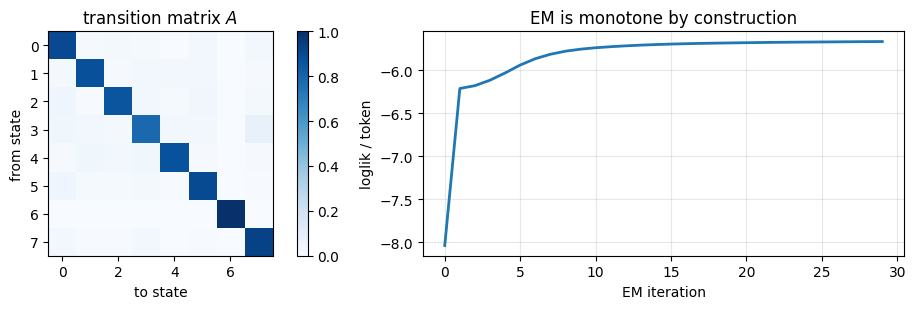

Diagonal dominance means the states are persistent -- the model has found
stretches of text that behave alike, not noise flipping every token.


In [8]:
plt.figure(figsize=(11, 3.2))
A = log_A.exp().numpy()
plt.subplot(1, 2, 1)
plt.imshow(A, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(fraction=.046); plt.title("transition matrix $A$")
plt.xlabel("to state"); plt.ylabel("from state")
plt.subplot(1, 2, 2)
plt.plot(hist, lw=2); plt.xlabel("EM iteration"); plt.ylabel("loglik / token")
plt.title("EM is monotone by construction"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Diagonal dominance means the states are persistent -- the model has found")
print("stretches of text that behave alike, not noise flipping every token.")

## 6 · The belief state, walking through a document

$b_t$ is a posterior over where you are, updated one word at a time. This is the
context map: everything the model carries forward about a forty-page filing is
these $K$ numbers.

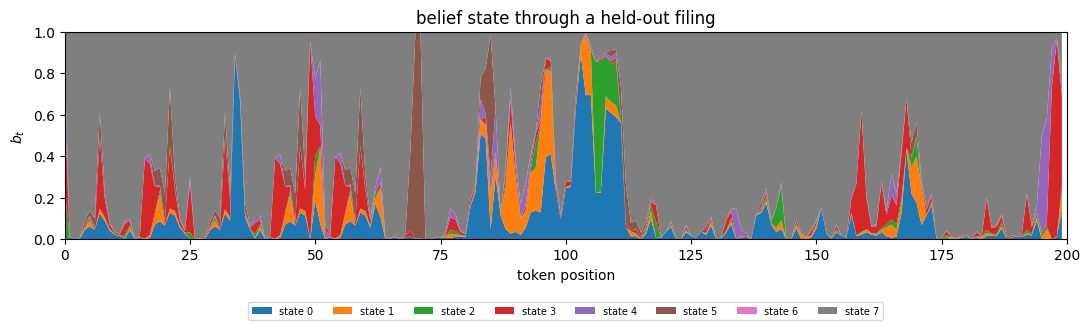

first 60 tokens, with the dominant state under each:

inc guinea bauxite mine cost of goods sold <unk> <unk> <unk> <unk> s a brazil <unk> generation facility cost of goods sold <unk> <unk> <unk> inc canada aluminum smelter cost of goods sold <unk> do <unk> o <unk> s a brazil <unk> generation facility cost of goods sold <unk> power limited partnership canada <unk> generation facility cost of goods sold
377777777777777777777377777777777700777777777773737177777773


In [9]:
seq = Xva[3:4]
la, ll = log_forward(log_pi, log_A, categorical_logB(seq, log_B))
b = (la - torch.logsumexp(la, dim=2, keepdim=True)).exp()[0].numpy()   # (L,K)

plt.figure(figsize=(11, 3.6))
plt.stackplot(np.arange(b.shape[0]), b.T, labels=[f"state {k}" for k in range(K)])
plt.xlim(0, b.shape[0]); plt.ylim(0, 1)
plt.xlabel("token position"); plt.ylabel("$b_t$")
plt.title("belief state through a held-out filing")
plt.legend(ncol=K, fontsize=7, loc="upper center", bbox_to_anchor=(.5, -.28))
plt.tight_layout(); plt.show()

dom = b.argmax(1)
print("first 60 tokens, with the dominant state under each:\n")
print(" ".join(itos[j] for j in seq[0, :60].tolist()))
print("".join(str(d) for d in dom[:60]))

## 7 · The bottleneck, measured

The lecture's claim: whatever the prefix contained, only $K-1$ numbers survive
into the future. That is testable. Sweep $K$ and plot held-out perplexity.

* If it keeps falling, the bottleneck is not binding at these sizes.
* If it **saturates**, you have located the capacity of the representation — and
  the reason the RNN swaps the simplex for a real vector.

The bigram count table is on the plot as a reference, and it is there to be
uncomfortable: expect the HMM to lose. This rung buys **horizon**, not accuracy,
and the honest version of the ladder says so.

In [10]:
def heldout_bits(Xh, log_pi, log_A, log_B):
    _, ll = log_forward(log_pi, log_A, categorical_logB(Xh, log_B))
    return -(ll.sum() / Xh.numel()).item() / math.log(2)

KS, sweep = [2, 4, 8, 16, 32], []
for k in KS:
    t0 = time.time()
    lp, lA, lB, _, _ = fit_hmm_categorical(Xtr, K=k, V=V, iters=25, verbose=False)
    b = heldout_bits(Xva, lp, lA, lB)
    sweep.append((k, b, 2**b))
    print(f"  K={k:>3}  held out {b:5.2f} bits  PP={2**b:8,.0f}   [{time.time()-t0:.0f}s]")

# bigram reference on the same held-out sequences
bi = collections.Counter(); row = collections.Counter()
for s in Xtr.tolist():
    for a, bb in zip(s, s[1:]): bi[(a, bb)] += 1; row[a] += 1
tot, kk = 0.0, 0.01
for s in Xva.tolist():
    for a, bb in zip(s, s[1:]):
        tot += -math.log2((bi[(a, bb)] + kk) / (row[a] + kk * V)); kk = 0.01
bits_bigram = tot / (Xva.numel() - Xva.shape[0])
print(f"\n  bigram count table (add-k): {bits_bigram:.2f} bits, PP={2**bits_bigram:,.0f}")

  K=  2  held out  8.67 bits  PP=     407   [18s]
  K=  4  held out  8.49 bits  PP=     359   [25s]
  K=  8  held out  8.27 bits  PP=     308   [45s]
  K= 16  held out  8.11 bits  PP=     276   [122s]
  K= 32  held out  7.97 bits  PP=     250   [921s]

  bigram count table (add-k): 6.75 bits, PP=108


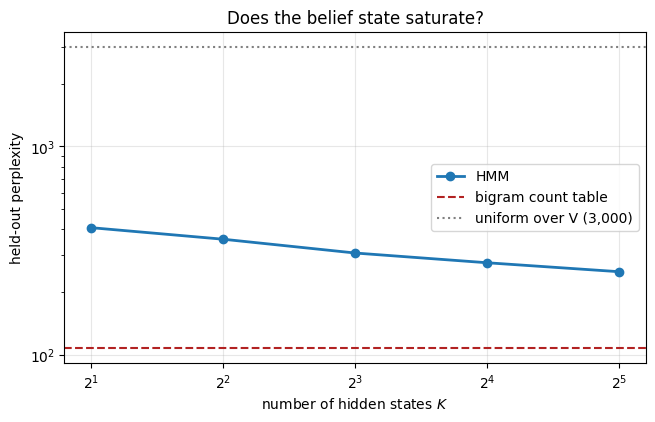

perplexity improvement per doubling of K:
    2 ->   4:  x1.14
    4 ->   8:  x1.16
    8 ->  16:  x1.11
   16 ->  32:  x1.10

The ratios are not monotone, but they trend toward 1.0 -- the bottleneck becoming visible.


In [11]:
ks = [s[0] for s in sweep]; pps = [s[2] for s in sweep]
plt.figure(figsize=(7.5, 4.3))
plt.plot(ks, pps, marker="o", lw=2, label="HMM")
plt.axhline(2**bits_bigram, ls="--", c="firebrick", label="bigram count table")
plt.axhline(V, ls=":", c="grey", label=f"uniform over V ({V:,})")
plt.xscale("log", base=2); plt.yscale("log")
plt.xlabel("number of hidden states $K$"); plt.ylabel("held-out perplexity")
plt.title("Does the belief state saturate?"); plt.legend(); plt.grid(alpha=.3)
plt.show()

gain = [pps[i-1] / pps[i] for i in range(1, len(pps))]
print("perplexity improvement per doubling of K:")
for (k0, _, _), (k1, _, _), g in zip(sweep, sweep[1:], gain):
    print(f"  {k0:>3} -> {k1:>3}:  x{g:.2f}")
print("\nThe ratios are not monotone, but they trend toward 1.0 -- the bottleneck becoming visible.")

## 8 · The same recursion, on returns

Nothing in the forward algorithm cared that the observations were words. Replace
the categorical emission with a Gaussian and the identical code is **Hamilton's
Markov-switching model** — the regime filter this room already uses.

First, ground truth: simulate a two-regime return process with known parameters
and check the filter recovers them. That is the only way to know a regime filter
is telling you something rather than fitting noise.

**One implementation note that cost me an hour.** Run this in `float64`. In
`float32` the Gaussian log-densities of daily returns ($\sigma \approx 0.006$)
lose enough precision that the EM likelihood decreases — which looks like a bug
in the algorithm and is not.

In [12]:
rng = np.random.default_rng(7)
A_true  = np.array([[0.985, 0.015], [0.060, 0.940]])
mu_true = np.array([0.0006, -0.0010])
sd_true = np.array([0.0060,  0.0230])

T, s = 6_000, 0
S_true = np.zeros(T, int); y = np.zeros(T)
for t in range(T):
    S_true[t] = s; y[t] = rng.normal(mu_true[s], sd_true[s]); s = rng.choice(2, p=A_true[s])

L  = 500
yt = torch.from_numpy(y[:T//L*L].reshape(-1, L)).double()

Kg = 2
log_pi_g = torch.log(torch.ones(Kg, dtype=torch.float64) / Kg)
log_A_g  = torch.log(torch.tensor([[.9,.1],[.1,.9]], dtype=torch.float64))
mu_g     = torch.tensor([y.mean(), y.mean()], dtype=torch.float64)
sd_g     = torch.tensor([y.std()*.5, y.std()*1.5], dtype=torch.float64)

prev = None
for it in range(80):
    log_pi_g, log_A_g, gamma_g, ll = baum_welch_step(
        log_pi_g, log_A_g, gaussian_logB(yt, mu_g, sd_g))
    mu_g, sd_g = m_step_gaussian(yt, gamma_g)
    if prev is not None and ll.item() < prev - 1e-9*abs(prev):
        print(f"  !! decrease at {it}: {ll.item()-prev:+.3e}")
    prev = ll.item()

hi = int(sd_g.argmax()); idx = [1-hi, hi]
print(f"  true   sigma {sd_true}          mu {mu_true}")
print(f"  fitted sigma {np.round(sd_g.numpy()[idx],4)}   mu {np.round(mu_g.numpy()[idx],5)}")
print(f"  true   A {A_true.round(3).tolist()}")
print(f"  fitted A {log_A_g.exp().numpy()[np.ix_(idx,idx)].round(3).tolist()}")

p_turb = gamma_g[:, :, hi].reshape(-1).numpy(); n = len(p_turb)
print(f"\n  classification accuracy vs the true regime: "
      f"{((p_turb>.5).astype(int) == S_true[:n]).mean():.1%}")
print(f"  mean P(turbulent) when truly calm      {p_turb[S_true[:n]==0].mean():.3f}")
print(f"  mean P(turbulent) when truly turbulent {p_turb[S_true[:n]==1].mean():.3f}")

  true   sigma [0.006 0.023]          mu [ 0.0006 -0.001 ]
  fitted sigma [0.006  0.0224]   mu [ 0.00054 -0.00225]
  true   A [[0.985, 0.015], [0.06, 0.94]]
  fitted A [[0.987, 0.013], [0.072, 0.928]]

  classification accuracy vs the true regime: 98.3%
  mean P(turbulent) when truly calm      0.017
  mean P(turbulent) when truly turbulent 0.911


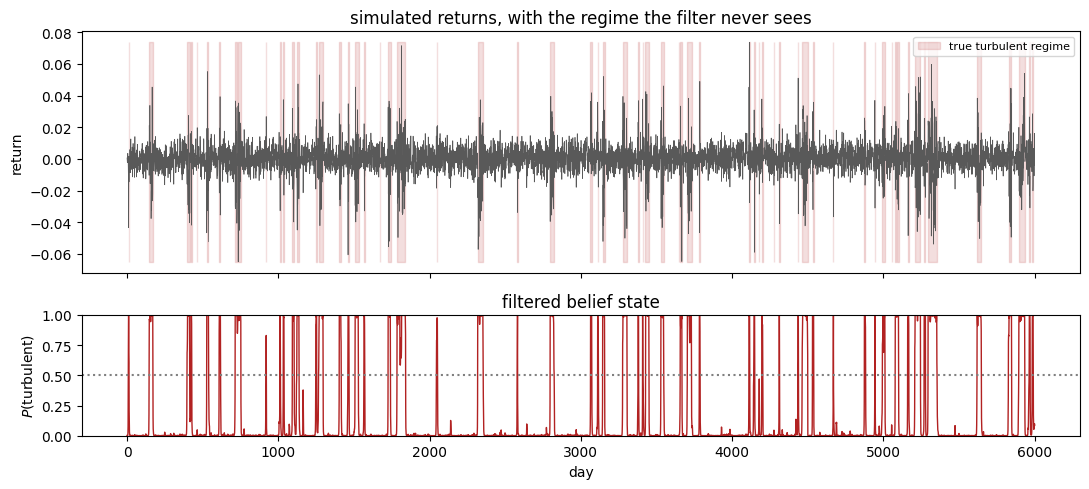

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(y[:n], lw=.5, c="0.35")
ax[0].fill_between(np.arange(n), y[:n].min(), y[:n].max(),
                   where=S_true[:n] == 1, alpha=.15, color="firebrick",
                   label="true turbulent regime")
ax[0].set_ylabel("return"); ax[0].legend(loc="upper right", fontsize=8)
ax[0].set_title("simulated returns, with the regime the filter never sees")
ax[1].plot(p_turb, lw=1, c="firebrick")
ax[1].axhline(.5, ls=":", c="grey")
ax[1].set_ylim(0, 1); ax[1].set_ylabel("$P(\\mathrm{turbulent})$")
ax[1].set_xlabel("day"); ax[1].set_title("filtered belief state")
plt.tight_layout(); plt.show()

That lower panel *is* the belief state from §6, on a different alphabet. Same
predict-then-update recursion, same $b_t$, same $O(TK^2)$ — only the emission
family changed, from a $K \times V$ table to $K$ pairs $(\mu, \sigma)$.

Which is the transferable point of this rung. Language modelling and time-series
econometrics solved the same problem independently, in different notation, and
mostly did not read each other.

annualised sigma: calm 10.7%, turbulent 32.6%
expected duration: calm 75 days, turbulent 27 days


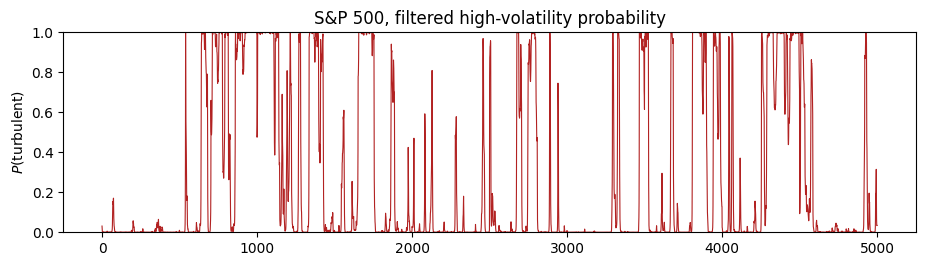

In [14]:
# --- optional: run it on real returns ---------------------------------------
# Not verified in this notebook -- yfinance availability varies. If it fails,
# the simulated result above is the one that carries the argument.
try:
    import yfinance as yf
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance",
                    "--break-system-packages"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance"], check=False)
    try: import yfinance as yf
    except ImportError: yf = None

if yf is not None:
    try:
        px = yf.download("^GSPC", start="2005-01-01", progress=False, auto_adjust=True)
        r  = np.log(px["Close"]).diff().dropna().values.ravel()
        Lr = 500; yr = torch.from_numpy(r[:len(r)//Lr*Lr].reshape(-1, Lr)).double()
        lp = torch.log(torch.ones(2, dtype=torch.float64)/2)
        lA = torch.log(torch.tensor([[.95,.05],[.05,.95]], dtype=torch.float64))
        m_ = torch.tensor([r.mean(), r.mean()], dtype=torch.float64)
        s_ = torch.tensor([r.std()*.6, r.std()*1.8], dtype=torch.float64)
        for _ in range(60):
            lp, lA, gm, _ = baum_welch_step(lp, lA, gaussian_logB(yr, m_, s_))
            m_, s_ = m_step_gaussian(yr, gm)
        h = int(s_.argmax())
        print(f"annualised sigma: calm {s_[1-h].item()*math.sqrt(252):.1%}, "
              f"turbulent {s_[h].item()*math.sqrt(252):.1%}")
        print(f"expected duration: calm {1/(1-lA.exp()[1-h,1-h].item()):.0f} days, "
              f"turbulent {1/(1-lA.exp()[h,h].item()):.0f} days")
        plt.figure(figsize=(11, 2.6))
        plt.plot(gm[:, :, h].reshape(-1).numpy(), lw=.8, c="firebrick")
        plt.ylim(0, 1); plt.ylabel("$P(\\mathrm{turbulent})$")
        plt.title("S&P 500, filtered high-volatility probability"); plt.show()
    except Exception as e:
        print("real-data path failed:", type(e).__name__, e)
        print("The simulated result above is the one that matters.")

## 9 · Exercises

1. **Where does $K$ stop paying?** Extend the §7 sweep to $K = 64, 128$. Plot the
   improvement ratio per doubling. If it crosses 1.05, you have measured the
   bottleneck, and the number is worth putting on a slide.

2. **Does the HMM beat the bigram anywhere?** It loses on average perplexity.
   Score the two models *per position* and find the positions where the HMM wins.
   The hypothesis to test: it wins where the useful evidence is far away, which
   is exactly what the rung claims to buy.

3. **Interpret the states.** Take the highest-occupancy state and print the
   longest stretch of a filing it dominates. Is it a section — Item 7A, the notes,
   the risk factors? If the states line up with document structure, the model
   found something a bigram cannot represent at all.

4. **Three regimes.** Refit §8 with $K = 3$. Does the third state split the calm
   period or the turbulent one, and is it stable across initialisations? EM is
   monotone but not globally convergent — run five seeds before believing it.

5. **The estimand, again.** $P(\text{turbulent})$ is a probability about a
   *latent state of the model*, not about the world. Write down what would have
   to be true for it to be a probability about anything a decision depends on.
   That question is Session 3.